# HS2026. Practice 1. Introduction to Notebooks and PyTorch.

---

# Keywords: tensor, function, computational graph, gradient, backward propagation, modules, optimizers, dense layer


# PyTorch

Let's check that the environment is sane:

In [3]:
import torch

In [2]:
torch.__version__

'2.8.0'

## Main concepts

#### Tensors
Tensors are the objects and results of all computations.

In [3]:
x = torch.tensor([1.0, 2.0])
x

tensor([1., 2.])

In [4]:
torch.zeros((2, 2))

tensor([[0., 0.],
        [0., 0.]])

In [5]:
torch.ones(3)

tensor([1., 1., 1.])

### Tensor indexing

In [6]:
x = torch.tensor([[1,2,3], [4,5,6]], dtype=torch.int32)

In [7]:
x

tensor([[1, 2, 3],
        [4, 5, 6]], dtype=torch.int32)

In [8]:
x[0,1]

tensor(2, dtype=torch.int32)

In [9]:
x[1]

tensor([4, 5, 6], dtype=torch.int32)

In [10]:
x[:,0]

tensor([1, 4], dtype=torch.int32)

In [11]:
x[:,0:3:2]

tensor([[1, 3],
        [4, 6]], dtype=torch.int32)

In [12]:
x[:, 1] = 1
x

tensor([[1, 1, 3],
        [4, 1, 6]], dtype=torch.int32)

### Tensor operations

In [13]:
torch.tensor([1.0, 2.0]) + torch.tensor([2.0, 3.0])

tensor([3., 5.])

In [14]:
torch.tensor([[2.0, 3.0], [4.0, 5.0]]) * torch.tensor([[1.0, 2.0]])

tensor([[ 2.,  6.],
        [ 4., 10.]])

In [15]:
torch.tensor([[2.0, 3.0], [4.0, 5.0]]) * torch.tensor([1.0, 2.0])

tensor([[ 2.,  6.],
        [ 4., 10.]])

In [16]:
torch.tensor([[2.0, 3.0], [4.0, 5.0]]) * torch.tensor([[1.0], [2.0]])

tensor([[ 2.,  3.],
        [ 8., 10.]])

There is also matrix multiplication --- the `@` operator (`torch.matmul`). Do not confuse it with `*`:

* `*` multiplies elementwise, broadcasting the vector across rows (as above): `[[2*1, 3*2], [4*1, 5*2]]`;
* `@` computes dot products of rows with the vector: `[2*1 + 3*2, 4*1 + 5*2]`.

In [17]:
torch.tensor([[2.0, 3.0], [4.0, 5.0]]) @ torch.tensor([1.0, 2.0])

tensor([ 8., 14.])

Tensor operations are vectorized: one operation on a whole tensor is much faster than an elementwise Python loop.

In [18]:
x = torch.zeros(1000000)

In [19]:
%%time
for i in range(1000000):
  x[i] = 1

CPU times: total: 5.17 s
Wall time: 5.25 s


In [20]:
%%time
x = x + 1

CPU times: total: 0 ns
Wall time: 1.21 ms


#### Computational graph


Functions and tensors can be used to build a computational graph.

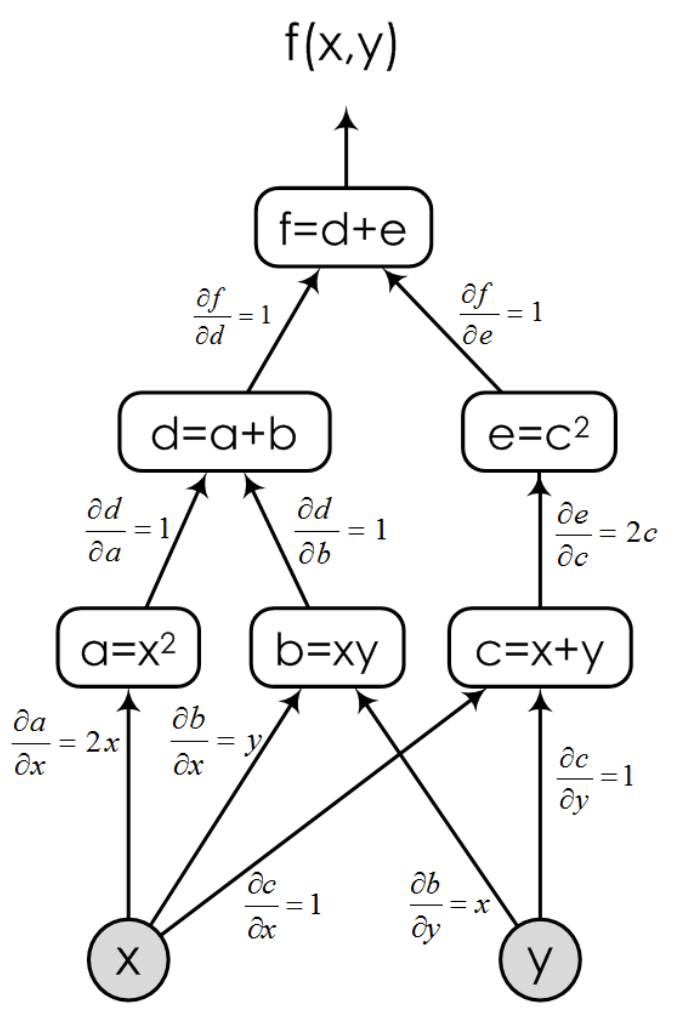

In PyTorch, computational graphs are implicit, but the concept of a graph can still help in understanding how it works.

For example, the graph in the picture above can be built like this:

In [21]:
x = torch.tensor(2.0, requires_grad=True) # requires_grad shows that this is a graph "input"
y = torch.tensor(2.0, requires_grad=True)
a = x ** 2
b = x * y
c = x + y
d = a + b
e = c ** 2
f = d + e
f

tensor(24., grad_fn=<AddBackward0>)

#### Functions
Functions are operations on tensors, which are combined into a computational graph.

In [113]:
from typing import Tuple

Assignment does not copy tensors --- both names refer to the same object. Note the difference between the out-of-place `y = y + 1` (creates a new tensor) and the in-place `y += 1` (modifies the existing one):

In [23]:
x = torch.tensor(1)

In [24]:
y = x
y

tensor(1)

In [25]:
y = y + 1
y

tensor(2)

In [26]:
x

tensor(1)

In [27]:
y += 1
y

tensor(3)

In [28]:
x

tensor(1)

Usually, there is no need to define functions, as PyTorch already has an excellent built-in function library. Most of the functions you'll need are already there or can be expressed as a composition of built-in functions. You can look for built-in functions in torch documentation here: https://pytorch.org/docs/stable/torch.html.

Still, we can define our own functions by subclassing `torch.autograd.Function` and implementing two static methods: `forward` (computes the value) and `backward` (computes the gradients of the inputs given the gradients of the outputs).

In [114]:
class MulConstant(torch.autograd.Function):
    # forward computes the function using inputs.
    @staticmethod
    def forward(ctx,
                tensor: torch.FloatTensor,
                constant: int) -> torch.FloatTensor:
        # ctx is a context object that can be used to stash information
        # for backward computation.
        ctx.constant = constant
        # Here we store constant in the context. Field name 'constant'
        # is arbitrary and we can use any name we want.
        result = torch.zeros_like(tensor)
        with torch.no_grad():
          for i in range(0, constant):
              result += tensor # same as result = torch.add(result, tensor)
        return result

    # backward compute derivatives during backward propagation.
    # Its inputs are gradients of outputs.
    @staticmethod
    def backward(ctx, grad_output: torch.FloatTensor) -> Tuple[torch.FloatTensor]:
        # We return as many input gradients as there were arguments.
        # Gradients of non-Tensor arguments to forward must be None.
        return grad_output * ctx.constant, None

In [30]:
x = torch.tensor(2.0, requires_grad=True)

In [31]:
MulConstant.apply(x, 3)

tensor(6., grad_fn=<MulConstantBackward>)

In [32]:
x

tensor(2., requires_grad=True)

Usually it's used like this:

In [33]:
mul_constant = MulConstant.apply
mul_constant(x, 3)

tensor(6., grad_fn=<MulConstantBackward>)

We can backward propagate through our custom function:

In [34]:
mul_constant(x, 3).backward()

The same function is already built into torch:

In [35]:
torch.mul(x, 3)

tensor(6., grad_fn=<MulBackward0>)

Operator syntax:

In [36]:
x * 3

tensor(6., grad_fn=<MulBackward0>)

As an exercise, let's implement addition and multiplication as custom functions:

In [115]:
class Add(torch.autograd.Function):
    @staticmethod
    def forward(ctx,
                tensor1: torch.FloatTensor,
                tensor2: torch.FloatTensor) -> torch.FloatTensor:
        with torch.no_grad():
          return tensor1 + tensor2

    @staticmethod
    def backward(ctx, grad_output: torch.FloatTensor) -> Tuple[torch.FloatTensor]:
        # This time both inputs are tensors, so we compute gradients
        # for both of them.
        return grad_output * 1, grad_output * 1

In [116]:
class Mul(torch.autograd.Function):
    @staticmethod
    def forward(ctx,
                tensor1: torch.FloatTensor,
                tensor2: torch.FloatTensor) -> torch.FloatTensor:
        ctx.tensor1 = tensor1
        ctx.tensor2 = tensor2
        # We store values of both tensors as we will need them for
        # backward propogation.
        with torch.no_grad():
          return tensor1 * tensor2

    @staticmethod
    def backward(ctx, grad_output: torch.FloatTensor) -> Tuple[torch.FloatTensor]:
        # This time both inputs are tensors, so we compute gradients
        # for both of them.
        return grad_output * ctx.tensor2, grad_output * ctx.tensor1

We can define new functions using Python and the built-in function library.


In [117]:
def mul(tensor: torch.FloatTensor, multiplier: int) -> torch.FloatTensor:
  result = torch.zeros_like(tensor)
  for i in range(0, multiplier):
    result += tensor # same as result = torch.add(result, tensor)
  return result

Gradients flow through such functions automatically:

In [40]:
mul(x, 3).backward()

In [41]:
x.grad

tensor(6.)

In [42]:
x.grad = torch.tensor(0.0)

Let's build the graph from the beginning of the section once again:

In [43]:
x = torch.tensor(2.0, requires_grad=True) # requires_grad shows that this is a graph "input"
y = torch.tensor(2.0, requires_grad=True)
a = x ** 2
b = x * y
c = x + y
d = a + b
e = c ** 2
f = d + e
f

tensor(24., grad_fn=<AddBackward0>)

Forward computation happened automatically while we were building the graph. `grad_fn` means that `f` is not just a tensor but has a computational graph associated with it (AddBackward implies that the "topmost" operation of this graph is Add). And we can backward propagate to compute gradients.

### Autograd

The core of all ML frameworks is the calculation of derivatives using backward propagation.

In [ ]:
f.backward()

In [ ]:
x.grad

In [ ]:
y.grad

Can we do this again? (The next cell raises an error --- this is intentional.)

In [ ]:
f.backward()

The graph was already removed. Torch optimizes memory consumption and removes the computational graph as soon as it is backward-propagated. Fortunately, the error message is pretty clear: we can retain the graph by specifying the `retain_graph=True` argument.

In [8]:
x = torch.tensor(2.0, requires_grad=True) # requires_grad shows that this is a graph "input"
y = torch.tensor(2.0, requires_grad=True)
a = x ** 2
b = x * y
c = x + y
d = a + b
e = c ** 2
f = d + e
f

tensor(24., grad_fn=<AddBackward0>)

In [9]:
f.backward(retain_graph=True)

In [10]:
x.grad

tensor(14.)

In [11]:
f.backward(retain_graph=True)

In [12]:
x.grad

tensor(28.)

The gradient is `28`? Torch does not "clean" the gradient value automatically (we'll find this pretty useful later), so we must clean it manually.

In [13]:
x.grad = torch.tensor(0.0)

In [14]:
f.backward()

In [15]:
x.grad

tensor(14.)

We can use this to compute gradients of any composite function.

In [16]:
def f(x: torch.FloatTensor, y: torch.FloatTensor) -> torch.FloatTensor:
  a = x ** 2
  b = x * y
  c = x + y
  d = a + b
  e = c ** 2
  return d + e

In [17]:
x.grad = torch.tensor(0.0)
f(x, y).backward()
x.grad

tensor(14.)

The graph is rebuilt each time we call the function, so we do not need to retain gradients.

In [18]:
x.grad = torch.tensor(0.0)
f(x, y).backward()
x.grad

tensor(14.)

A single step of gradient descent can look like this:

In [19]:
lr = 0.01

In [20]:
x = x - lr * x.grad

In [21]:
x

tensor(1.8600, grad_fn=<SubBackward0>)

This update has a problem. The subtraction was recorded in the graph, like any other operation, so the new `x`:

* is not a graph input (leaf) anymore --- the next `backward` will not write into `x.grad`;
* carries the whole history of updates with it --- the graph grows on every iteration.

So before the next update we need `detach()`: it returns a tensor with the same value, but disconnected from the graph.

In [22]:
x = x.detach()

In [23]:
x

tensor(1.8600)

Now x is a leaf tensor (detached from the graph), but it does not have gradients enabled. To turn them on we have to use the `requires_grad_` function. This function sets the `requires_grad` parameter of the tensor to `True`.
Note the `_` at the end. In PyTorch naming convention this denotes in-place functions, which alter the existing tensor instead of creating a new one.

In [24]:
x.requires_grad_()
x

tensor(1.8600, requires_grad=True)

# High Level Concepts

## Modules

Modules help to organize and compose functions and inputs (weights) together.

In [25]:
from torch import nn
from torch.nn import init
from torch.nn.modules import loss
import math
import torch

Some examples:

In [26]:
relu = nn.ReLU()
relu


ReLU()

In [27]:
x = torch.tensor([40])
relu(x)

tensor([40])

In [28]:
dropout = nn.Dropout(0.5)
dropout

Dropout(p=0.5, inplace=False)

In [31]:
dropout(torch.tensor([1.0,2.0,3.0,4.0,5.0,6.0]))


tensor([ 0.,  4.,  6.,  0., 10.,  0.])

In [32]:
tanh = nn.Tanh()
tanh

Tanh()

In [33]:
linear = nn.Linear(10, 10)
linear

Linear(in_features=10, out_features=10, bias=True)

In [37]:
linear(torch.tensor([1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,0.0]))

tensor([-0.9123,  3.9151, -4.7446,  2.0338, -2.6377, -3.2548, -0.5909, -0.2717,
         1.1632, -1.0010], grad_fn=<ViewBackward0>)

In [38]:
sequential = nn.Sequential(nn.Linear(10, 100), nn.Tanh(), nn.Linear(100,100), nn.Tanh(), nn.Linear(100,10))
sequential

Sequential(
  (0): Linear(in_features=10, out_features=100, bias=True)
  (1): Tanh()
  (2): Linear(in_features=100, out_features=100, bias=True)
  (3): Tanh()
  (4): Linear(in_features=100, out_features=10, bias=True)
)

In [40]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.lin1 = nn.Linear(10,100)
        self.act1 = nn.Tanh()
        self.lin2 = nn.Linear(100,100)
        self.lin3 = nn.Linear(100,100)
        self.lin4 = nn.Linear(100,10)

    def forward(self, x):
        y = x
        x = self.lin1(x)
        x = self.act1(x)
        x = self.lin2(x)
        x = self.act1(x)
        x = self.lin3(x)
        x = self.act1(x)
        x = self.lin4(x) + y
        return x
net = Net()
net


Net(
  (lin1): Linear(in_features=10, out_features=100, bias=True)
  (act1): Tanh()
  (lin2): Linear(in_features=100, out_features=100, bias=True)
  (lin3): Linear(in_features=100, out_features=100, bias=True)
  (lin4): Linear(in_features=100, out_features=10, bias=True)
)

In [41]:
cross_entropy = loss.CrossEntropyLoss()
cross_entropy


CrossEntropyLoss()

In [42]:
from torch.nn import Module

In [43]:
from torch.nn import Parameter

We can define our own modules by subclassing the `Module` class.

Modules can have constant parameters (arguments).

In [45]:
class Power(Module):

    __constants__ = ['exponent']

    def __init__(self, exponent=3):
        super().__init__()
        self.exponent = exponent

    def forward(self, input):
        return torch.pow(input, self.exponent)

    def extra_repr(self):
        return f'exponent={self.exponent}'

In [46]:
power=Power(3)

In [47]:
power

Power(exponent=3)

In [48]:
Power.__constants__

['exponent']

In [49]:
power(torch.Tensor([2, 3.0]))

tensor([ 8., 27.])

and trainable parameters (weights).

In [50]:
class WPower(Module):
    def __init__(self, ):
        super().__init__()
        self.exponent = Parameter(torch.Tensor(1))
        self.reset_parameters()

    def reset_parameters(self):
        init.uniform_(self.exponent, a=-math.sqrt(5), b=math.sqrt(5))

    def forward(self, input):
        return torch.pow(input, self.exponent)


In [52]:
wpower=WPower()

In [53]:
list(wpower.parameters())

[Parameter containing:
 tensor([1.4004], requires_grad=True)]

In [54]:
wpower.exponent

Parameter containing:
tensor([1.4004], requires_grad=True)

## Parameters

Some models are not just functions, but they also have internal parameters (weights/graph inputs).

In [55]:
list(linear.parameters())


[Parameter containing:
 tensor([[-0.0218, -0.0140,  0.1446, -0.2625,  0.2434,  0.0256, -0.2616, -0.1490,
           0.1644, -0.1338],
         [-0.2413, -0.0045, -0.1252, -0.0971, -0.1371,  0.1680,  0.1369,  0.3045,
           0.1526, -0.1004],
         [-0.0274, -0.0909, -0.0508, -0.1474, -0.2861, -0.1210,  0.1794, -0.1395,
          -0.2084,  0.1809],
         [-0.2738,  0.0481, -0.2329,  0.2896, -0.2803,  0.2598,  0.1876,  0.1703,
          -0.1169, -0.3102],
         [-0.0885,  0.2362,  0.0463, -0.0182,  0.0280,  0.2067, -0.2537, -0.1609,
          -0.1886,  0.0351],
         [ 0.0198, -0.3073, -0.1375, -0.0409, -0.0857, -0.2530, -0.3035, -0.0138,
           0.2335,  0.1748],
         [-0.2605,  0.2964,  0.1513, -0.0155, -0.3151, -0.2690, -0.1080,  0.2611,
           0.0929,  0.0129],
         [ 0.1588,  0.1086,  0.2496, -0.2189, -0.1172,  0.2057,  0.0345,  0.0880,
          -0.2552, -0.2757],
         [ 0.1722,  0.1594,  0.2360,  0.0192, -0.0313, -0.2255,  0.0839, -0.2338,
       

In [56]:
linear.weight


Parameter containing:
tensor([[-0.0218, -0.0140,  0.1446, -0.2625,  0.2434,  0.0256, -0.2616, -0.1490,
          0.1644, -0.1338],
        [-0.2413, -0.0045, -0.1252, -0.0971, -0.1371,  0.1680,  0.1369,  0.3045,
          0.1526, -0.1004],
        [-0.0274, -0.0909, -0.0508, -0.1474, -0.2861, -0.1210,  0.1794, -0.1395,
         -0.2084,  0.1809],
        [-0.2738,  0.0481, -0.2329,  0.2896, -0.2803,  0.2598,  0.1876,  0.1703,
         -0.1169, -0.3102],
        [-0.0885,  0.2362,  0.0463, -0.0182,  0.0280,  0.2067, -0.2537, -0.1609,
         -0.1886,  0.0351],
        [ 0.0198, -0.3073, -0.1375, -0.0409, -0.0857, -0.2530, -0.3035, -0.0138,
          0.2335,  0.1748],
        [-0.2605,  0.2964,  0.1513, -0.0155, -0.3151, -0.2690, -0.1080,  0.2611,
          0.0929,  0.0129],
        [ 0.1588,  0.1086,  0.2496, -0.2189, -0.1172,  0.2057,  0.0345,  0.0880,
         -0.2552, -0.2757],
        [ 0.1722,  0.1594,  0.2360,  0.0192, -0.0313, -0.2255,  0.0839, -0.2338,
          0.2748,  0.0145

In [57]:
linear.bias


Parameter containing:
tensor([-0.0728, -0.1602,  0.0988, -0.0284,  0.2924, -0.0044, -0.2941,  0.1818,
         0.2061, -0.1704], requires_grad=True)

In [58]:
list(tanh.parameters())


[]

In [59]:
list(dropout.parameters())


[]

In [60]:
dropout.p

0.5

In [61]:
list(cross_entropy.parameters())


[]

In [62]:
list(map(lambda x: x.shape, list(sequential.parameters())))


[torch.Size([100, 10]),
 torch.Size([100]),
 torch.Size([100, 100]),
 torch.Size([100]),
 torch.Size([10, 100]),
 torch.Size([10])]

In [63]:
list(map(lambda x: x.shape, list(net.parameters())))


[torch.Size([100, 10]),
 torch.Size([100]),
 torch.Size([100, 100]),
 torch.Size([100]),
 torch.Size([100, 100]),
 torch.Size([100]),
 torch.Size([10, 100]),
 torch.Size([10])]

In [64]:
list(map(lambda x: x.requires_grad, list(net.parameters())))


[True, True, True, True, True, True, True, True]

## Eval

Each module can be in either `eval` or `train` state.

In [65]:
dropout.train()


Dropout(p=0.5, inplace=False)

In [66]:
net.eval()

Net(
  (lin1): Linear(in_features=10, out_features=100, bias=True)
  (act1): Tanh()
  (lin2): Linear(in_features=100, out_features=100, bias=True)
  (lin3): Linear(in_features=100, out_features=100, bias=True)
  (lin4): Linear(in_features=100, out_features=10, bias=True)
)

In [67]:
dropout(torch.ones(10))


tensor([0., 2., 2., 2., 0., 2., 0., 0., 0., 2.])

In [68]:
dropout.eval()


Dropout(p=0.5, inplace=False)

In [69]:
dropout(torch.ones(10))

tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [70]:
newseq = nn.Sequential(nn.Dropout(), nn.Dropout())
newseq(torch.ones(10))


tensor([0., 0., 0., 0., 4., 0., 4., 0., 4., 0.])

In [71]:
newseq.eval()
newseq(torch.ones(10))

tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

**Important**! Train/eval mode has nothing to do with weight training. It just changes the behavior of some modules (e.g. `dropout`, `batchnorm`). For composite modules `.eval()`/`.train()` sets the corresponding mode for each of its components.

## Initialization

Most modules have a default way of parameter initialization, but sometimes we might want to init them explicitly.

In [72]:
linear.weight

Parameter containing:
tensor([[-0.0218, -0.0140,  0.1446, -0.2625,  0.2434,  0.0256, -0.2616, -0.1490,
          0.1644, -0.1338],
        [-0.2413, -0.0045, -0.1252, -0.0971, -0.1371,  0.1680,  0.1369,  0.3045,
          0.1526, -0.1004],
        [-0.0274, -0.0909, -0.0508, -0.1474, -0.2861, -0.1210,  0.1794, -0.1395,
         -0.2084,  0.1809],
        [-0.2738,  0.0481, -0.2329,  0.2896, -0.2803,  0.2598,  0.1876,  0.1703,
         -0.1169, -0.3102],
        [-0.0885,  0.2362,  0.0463, -0.0182,  0.0280,  0.2067, -0.2537, -0.1609,
         -0.1886,  0.0351],
        [ 0.0198, -0.3073, -0.1375, -0.0409, -0.0857, -0.2530, -0.3035, -0.0138,
          0.2335,  0.1748],
        [-0.2605,  0.2964,  0.1513, -0.0155, -0.3151, -0.2690, -0.1080,  0.2611,
          0.0929,  0.0129],
        [ 0.1588,  0.1086,  0.2496, -0.2189, -0.1172,  0.2057,  0.0345,  0.0880,
         -0.2552, -0.2757],
        [ 0.1722,  0.1594,  0.2360,  0.0192, -0.0313, -0.2255,  0.0839, -0.2338,
          0.2748,  0.0145

In [73]:
init.xavier_uniform_(linear.weight) # Kaiming uniform by default


Parameter containing:
tensor([[-0.1325, -0.2511,  0.5143, -0.5009,  0.1870,  0.4256,  0.5030, -0.3566,
          0.0057,  0.1157],
        [-0.1721, -0.2461, -0.3738, -0.0892,  0.1656,  0.2983,  0.2384,  0.5304,
         -0.1156, -0.1976],
        [ 0.0565, -0.0688, -0.2297, -0.0319,  0.3987,  0.1239, -0.2420,  0.3516,
         -0.5250, -0.3495],
        [-0.2557, -0.2930,  0.4578,  0.2249, -0.5022, -0.2030, -0.4452, -0.2179,
         -0.5041, -0.0238],
        [-0.0468,  0.0118, -0.5362, -0.2436,  0.0164,  0.2773, -0.3279,  0.4204,
          0.4961, -0.5144],
        [-0.2930, -0.5443, -0.2406,  0.2575,  0.3007, -0.1435, -0.0532, -0.1572,
          0.1015, -0.2743],
        [ 0.2571, -0.3488,  0.4665,  0.2763,  0.1801, -0.3777,  0.5273, -0.1263,
          0.4503, -0.0033],
        [-0.1816,  0.5346, -0.3104,  0.0371,  0.1663,  0.3245, -0.2158,  0.3587,
          0.5204, -0.2756],
        [-0.4286,  0.4121, -0.4223,  0.1844, -0.0545,  0.1077, -0.2117, -0.3733,
         -0.1981,  0.1818

In [74]:
init.constant_(linear.weight, 1.0)


Parameter containing:
tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]], requires_grad=True)

In [75]:
list(linear.parameters())


[Parameter containing:
 tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]], requires_grad=True),
 Parameter containing:
 tensor([-0.0728, -0.1602,  0.0988, -0.0284,  0.2924, -0.0044, -0.2941,  0.1818,
          0.2061, -0.1704], requires_grad=True)]

In [76]:
for param in linear.parameters():
    init.uniform_(param, -12, 12)
list(linear.parameters())

[Parameter containing:
 tensor([[  9.3605,  -2.6355,   2.9453,  -3.0501, -10.9977,   0.1947,   1.0956,
            9.3036,   5.4812,  10.5412],
         [ -6.0794,  -7.6467,   6.2478,   1.9563,   9.1537,   1.9093,   1.0792,
            2.2437,   4.5161,  -1.5781],
         [ 11.5702,  -5.0287, -10.4142,   0.7862,   8.4661,   1.6780,   0.1781,
            6.8205,  -1.2910,  -9.8435],
         [ -7.9926,  -1.2217,  -6.5674,  -4.4352,  -3.3908,  -1.9644,  -2.3771,
            8.1350,   7.2363,  11.2555],
         [ -7.2072, -10.9666,   6.6346,   6.9857,   4.7414,   8.9370,   1.9154,
           10.0921,   0.8035,   4.8302],
         [-11.4370,   0.5868,  -6.3381,  -7.4640,   6.3004,   6.7280,   6.3926,
           -5.6068,  -6.9007,  -8.6698],
         [ -8.9934,  10.9967,   8.8188,  -7.0151,  -3.9376,   8.9382,   6.0510,
           -4.9137,  -9.9639,  -2.7690],
         [  4.6855,  -4.5277,  -1.5799,   0.6729,  -9.7475,   4.3540,  -2.7401,
           -9.3143,   0.1256, -11.8818],
         

You can find more initialization functions here: https://pytorch.org/docs/master/nn.html#torch-nn-init.

## Optimizers

Torch has a rich collection of optimizers built-in, but for now we will use just a vanilla stochastic gradient descent.

In [77]:
import torch.optim as optim

In [78]:
x = torch.tensor([1.0], requires_grad = True)

An optimizer gets the list of parameters it should update and a learning rate:

In [79]:
sgd = optim.SGD([x], lr=0.1)

In [80]:
y = x * 2


In [81]:
y.backward()

In [82]:
x.grad

tensor([2.])

`step()` performs a single update using the currently stored gradients:

In [83]:
sgd.step()

In [84]:
x

tensor([0.8000], requires_grad=True)

In [85]:
x.grad


tensor([2.])

`zero_grad()` clears the gradients of all tracked parameters:

In [86]:
sgd.zero_grad()


In [87]:
x.grad


# First Training Loop

In [93]:
from torchvision import datasets, transforms

Let's download MNIST --- a dataset of handwritten digits.

In [94]:
train_dataset = datasets.MNIST('./data', train=True, download=True,
                                transform=transforms.Compose([
                                    transforms.ToTensor(),
                                    transforms.Normalize((0.1307,), (0.3081,))
                                ]))


100%|██████████| 9.91M/9.91M [00:01<00:00, 6.45MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 199kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.52MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.83MB/s]


In [95]:
test_dataset = datasets.MNIST('./data', train=False, download=True,
                                transform=transforms.Compose([
                                    transforms.ToTensor(),
                                    transforms.Normalize((0.1307,), (0.3081,))
                                ]))

Dataloaders are responsible for data loading. They help us split the dataset into batches and shuffle it (otherwise each batch would contain only variants of a single digit). We will look inside them later.

In [96]:
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

A few helpers to look at the dataset images:

In [97]:
import matplotlib.pyplot as plt
toPIL = transforms.ToPILImage()

In [98]:
def denormalize(img):
  return img * 0.3081 + 0.1307

In [99]:
def example(i):
    print(train_dataset[i][1])
    return toPIL(denormalize(train_dataset[i][0])).resize((256, 256))

0


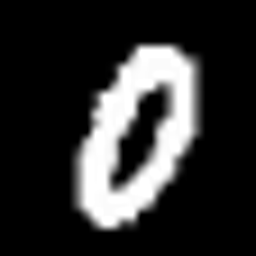

In [100]:
example(34)


Let's inspect one batch --- the labels and the tensor shape:

In [101]:
next(iter(train_loader))[1]


tensor([2, 9, 3, 0, 7, 4, 4, 2, 5, 4, 8, 6, 1, 7, 1, 8, 5, 6, 7, 5, 7, 8, 9, 4,
        2, 0, 1, 6, 5, 8, 1, 4, 5, 8, 3, 8, 0, 3, 5, 4, 7, 9, 1, 2, 3, 8, 8, 9,
        9, 1, 4, 8, 1, 2, 0, 4, 4, 3, 8, 6, 5, 3, 5, 1])

In [102]:
next(iter(train_loader))[0].shape


torch.Size([64, 1, 28, 28])

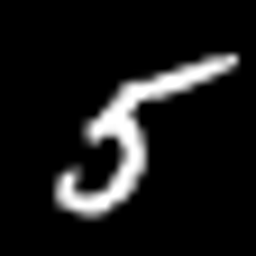

In [103]:
toPIL(denormalize(next(iter(train_loader))[0][0])).resize((256,256))

Each 28x28 image will be flattened by the `Flatten` module into a vector of 784 numbers, so a batch becomes `[64, 784]`:

In [89]:
28*28

784

In [104]:
model = nn.Sequential(nn.Flatten(),
                      nn.Linear(784, 512),
                      nn.Tanh(),
                      nn.Linear(512, 64),
                      nn.Tanh(),
                      nn.Linear(64, 10))


In [107]:
print(list(model.parameters()))

[Parameter containing:
tensor([[-0.0249,  0.0338, -0.0188,  ...,  0.0162, -0.0242,  0.0153],
        [-0.0132, -0.0074, -0.0337,  ..., -0.0206, -0.0237, -0.0011],
        [ 0.0129,  0.0079, -0.0271,  ...,  0.0263,  0.0166,  0.0352],
        ...,
        [ 0.0304,  0.0163,  0.0209,  ...,  0.0217,  0.0191,  0.0247],
        [-0.0285,  0.0293, -0.0142,  ..., -0.0243,  0.0331,  0.0129],
        [-0.0235, -0.0116, -0.0324,  ...,  0.0101, -0.0005,  0.0083]],
       requires_grad=True), Parameter containing:
tensor([ 2.6153e-02,  2.7375e-02,  1.5033e-02,  2.3210e-03, -3.0395e-02,
        -2.5150e-03,  2.7378e-02, -1.2037e-02,  2.1186e-02, -2.7359e-02,
         8.5501e-03,  2.4892e-02, -2.3885e-02,  1.9103e-02,  6.6254e-04,
        -1.1548e-02, -3.7477e-03, -2.7071e-02, -1.7476e-02, -7.9094e-03,
         3.2540e-02, -3.0855e-02,  1.5524e-02,  3.2842e-02, -2.6648e-02,
         6.7761e-03,  2.4058e-02, -2.2599e-02,  3.0475e-02,  5.7746e-03,
         9.1782e-03,  9.1880e-04, -2.5352e-03, -7.0372e

Why do we need the `Flatten` module?

---


Set up an optimizer:


In [105]:
optimizer = optim.SGD(model.parameters(), lr=0.1)

Choose a loss function:

In [108]:
loss_function = loss.CrossEntropyLoss()


And start training:

In [109]:
def train(model, train_loader, optimizer, loss_function, epoch):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()
        output = model(data)
        loss = loss_function(output, target)
        loss.backward()
        optimizer.step()
        if batch_idx % 200 == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.item()))

In [110]:
def test(model, test_loader, loss_function):
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            output = model(data)
            test_loss += loss_function(output, target).item() * data.size(0)
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()

    test_loss /= len(test_loader.dataset)

    print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
        test_loss, correct, len(test_loader.dataset),
        100. * correct / len(test_loader.dataset)))

In [111]:
for epoch in range(1, 20):
        train(model, train_loader, optimizer, loss_function, epoch)
        test(model, test_loader, loss_function)

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.336277
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.297388
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.186771
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.153645
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.227415

Test set: Average loss: 0.1639, Accuracy: 9509/10000 (95%)

Train Epoch: 2 [0/60000 (0%)]	Loss: 0.068750
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.125083
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.090659
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.173296
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.101954

Test set: Average loss: 0.1351, Accuracy: 9579/10000 (96%)

Train Epoch: 3 [0/60000 (0%)]	Loss: 0.076321
Train Epoch: 3 [12800/60000 (21%)]	Loss: 0.088496
Train Epoch: 3 [25600/60000 (43%)]	Loss: 0.027515
Train Epoch: 3 [38400/60000 (64%)]	Loss: 0.026773
Train Epoch: 3 [51200/60000 (85%)]	Loss: 0.155640

Test set: Average loss: 0.0917, Accuracy: 9717/10000 (97%)

Train Epoch: 4 [0/60000 (0%)]	Loss: 0.119676
Train Epoch: 4 [12800/60000 (21%)]	Lo

---

# Assignments & Organization


## Grading


* 60% - Homework assignments [~5 points a day, ~60 total]

* 20% - Midterm presentation

* 20% - Final presentation

## Assignment [5]


## Due by 8:00, 15.06.2026


## 1. Power function [1]

Implement a natural power autograd function for FloatTensor, using addition and multiplication.

In [136]:
class Power(torch.autograd.Function):
    @staticmethod
    def forward(ctx,
                tensor: torch.FloatTensor,
                power: int) -> torch.FloatTensor:
        ctx.power = power
        ctx.save_for_backward(tensor)
        result = tensor
        for i in range(power - 1):
            result = Mul.apply(result, tensor)
        return result

    @staticmethod
    def backward(ctx,
                 grad_output: torch.FloatTensor) -> Tuple[torch.FloatTensor]:
        tensor, = ctx.saved_tensors
        power = ctx.power
        
        # Compute x^(n-1)
        x_pow = tensor
        for i in range(power - 2):
            x_pow = Mul.apply(x_pow, tensor)
        
        # Compute n * x^(n-1) using Add
        n_times_x_pow = torch.zeros_like(tensor)
        for i in range(power):
            n_times_x_pow = Add.apply(n_times_x_pow, x_pow)
        
        # Compute n * x^(n-1) * grad_output
        return Mul.apply(n_times_x_pow, grad_output), None

In [137]:
assert(torch.all(Power.apply(torch.tensor([1.0, 2.0, 3.0]), 2) == torch.tensor([1.0, 4.0, 9.0])))
assert(torch.all(Power.apply(torch.tensor([1.0, 2.0, 3.0]), 3) == torch.tensor([1.0, 8.0, 27.0])))

Test that it works as expected. Test that gradients are computed correctly (even for composite functions using Power).

In [138]:
# 2. Gradient of x^2 at x=3 → should be 2*3 = 6
x = torch.tensor([3.0], requires_grad=True)
y = Power.apply(x, 2)
y.backward()
assert torch.allclose(x.grad, torch.tensor([6.0])), f"Got {x.grad}"
print("Gradient x^2: OK")

Gradient x^2: OK


In [139]:
# Composite: y = x^2 + x^3, dy/dx = 2x + 3x^2
# At x=2: dy/dx = 4 + 12 = 16
x = torch.tensor([2.0], requires_grad=True)
y = Add.apply(Power.apply(x, 2), Power.apply(x, 3))
y.backward()
assert torch.allclose(x.grad, torch.tensor([16.0])), f"Got {x.grad}"
print("Composite gradient: OK")

Composite gradient: OK


## 2. Polynomial [2]

Find a zero of the following polynomial up to five decimal places (i.e. if x^ is the result you found and x is the real root, |x - x^| should not exceed 5e-6):

In [142]:
def poly(x: torch.FloatTensor) -> torch.FloatTensor:
  return x**7 + 5 * x**3  + 17 * x -9

Using binary search https://en.wikipedia.org/wiki/Binary_search_algorithm:

In [141]:
from typing import Callable

In [143]:
def bin_search_find_zero(poly: Callable[[torch.FloatTensor],
                                        torch.FloatTensor]) -> torch.FloatTensor:
    eps = 1e-5    # eps/2 = 5e-6
    # Answer is in range [0, 1]
    a = torch.tensor(0.0)
    b = torch.tensor(1.0)
    max_iterations = 1000
    for iteration in range(max_iterations):
        if (b - a).abs().item() <= eps:
            print(f"# iterations: {iteration}")
            break
        midpoint = (a + b) / 2
        poly_mid = poly(midpoint)
        # Detach poly_mid to use Python if-else (Gemini suggestion)
        if poly_mid.item() > 0:
            b = midpoint
        else:
            a = midpoint
    return (a + b) / 2

In [144]:
root = bin_search_find_zero(poly)
root

# iterations: 17


tensor(0.4936)

Using Newton's method https://en.wikipedia.org/wiki/Newton%27s_method
(hint: use `backward` to compute derivatives):


In [146]:
def newton_find_zero(poly: Callable[[torch.FloatTensor],
                                    torch.FloatTensor]) -> torch.FloatTensor:
    x = torch.tensor(1.0, requires_grad=True)
    # This eps is for poly(x) being close to zero, derived from the x-tolerance
    eps_f = 1e-4 # Derived from f'(root) * 5e-6, roughly 20.76 * 5e-6
    max_iterations = 1000
    for iteration in range(max_iterations):
        # Zero out gradients from previous iterations
        if x.grad is not None:
            x.grad.zero_()

        poly_x = poly(x)

        # Check stopping criterion:
        # Is the function value close enough to zero?
        if poly_x.abs().item() <= eps_f:
            print(f"# iterations: {iteration}")
            break

        poly_x.backward()

        grad_x = x.grad

        # To ensure the gradient is not zero to avoid division by zero
        if grad_x.abs().item() < 1e-8:
            print("Gradient is too close to zero, stop.")
            break

        with torch.no_grad():
            x_new = x - poly_x / grad_x

        # Update x for the next iteration,
        # detaching to break graph and re-enabling gradients
        x = x_new.detach()
        x.requires_grad_(True)
    return x.detach()

Explain why the answer returned is correct up to five decimal places.

In [147]:
root = newton_find_zero(poly)
root

# iterations: 4


tensor(0.4936)

## 3. MNIST playground [1]


1. Finish training on the MNIST dataset. Find some examples where your model gives an incorrect answer and show them. (Note: the `example()` function we defined in class shows training-set images by index --- adapt it, or write a similar one, for the test set.)
2. Draw a confusion matrix for your model on the test dataset. A confusion matrix is a 10x10 matrix where cell `(i,j)` contains the number of digits `i` classified as digit `j`.
3. By default, the weight of a linear layer is initialized with the `kaiming_uniform` function and the bias is initialized with the `uniform` function (see the `reset_parameters` method of the Linear class https://github.com/pytorch/pytorch/blob/master/torch/nn/modules/linear.py). Initialize all weights as `uniform(-0.1,0.1)` and test. How does this modification affect the training process? Is it faster/slower? Is the end result better/worse? Same question for `uniform(-1, 1)`. Same question for `constant(0)` initialization. Don't forget to recreate the optimizer for your new model (otherwise you'll optimize parameters of the old model using values from the new one, which does not work).
4. Change the output dimension of the first linear layer (and the input of the second) to `256`, then to `1024`. How does this modification affect the training process? How does the number of model parameters change?

### Task 3.1

In [148]:
import matplotlib.pyplot as plt

In [151]:
# Collect all misclassified test indices
def get_mistakes(model, test_dataset):
    model.eval()
    wrong_indices = []
    wrong_preds = []

    with torch.no_grad():
        for i in range(len(test_dataset)):
            img, true_label = test_dataset[i]
            output = model(img.unsqueeze(0))
            pred = output.argmax(dim=1).item()
            if pred != true_label:
                wrong_indices.append(i)
                wrong_preds.append(pred)

    print(f"Total mistakes: {len(wrong_indices)} / {len(test_dataset)}")
    return wrong_indices, wrong_preds


Total mistakes: 160 / 10000


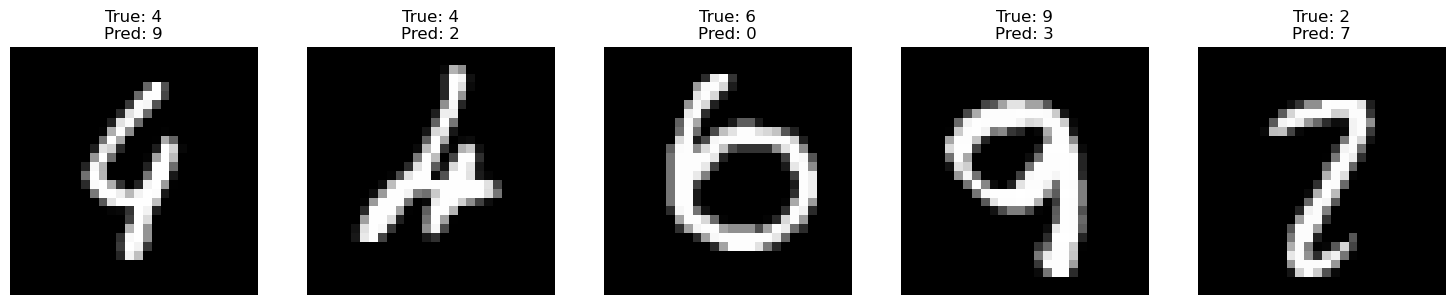

In [153]:
# Show first 5 mistakes
fig, axes = plt.subplots(1, 5, figsize=(15, 3))

wrong_indices, wrong_preds = get_mistakes(model, test_dataset)
for pos, ax in enumerate(axes):
    i = wrong_indices[pos]
    true_label = test_dataset[i][1]
    pred_label = wrong_preds[pos]
    img = toPIL(denormalize(test_dataset[i][0]))
    ax.imshow(img, cmap='gray')
    ax.set_title(f"True: {true_label}\nPred: {pred_label}")
    ax.axis('off')
plt.tight_layout()
plt.show()

### Task 3.2

In [154]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [155]:
# Collect all labels and predictions
model.eval()
all_true, all_pred = [], []

with torch.no_grad():
    for images, labels in test_loader:
        preds = model(images).argmax(dim=1)
        all_true.extend(labels.numpy())
        all_pred.extend(preds.numpy())

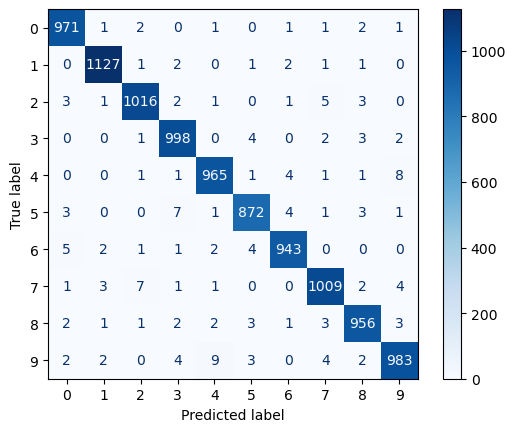

In [156]:
# Plot confusion matrix
cm = confusion_matrix(all_true, all_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=range(10))
disp.plot(cmap='Blues')
plt.show()

## 4. Custom linear module [1]


Implement your own linear module, such that `output = 100 * (inputs @ weights.T + biases)`. Take the MNIST network we trained in class (`nn.Sequential` of `Flatten`, `Linear(784, 512)`, `Tanh`, `Linear(512, 64)`, `Tanh`, `Linear(64, 10)`) and replace all the `Linear` layers with your module, then train it on MNIST. How does this modification affect the training process? How and why should we change the initialization and the learning rate of the optimizer, so that the network trains as well as before?